In [1]:
# ==============================================================================
# BLOCO 1: IMPORTAÇÃO DE BIBLIOTECAS
# ==============================================================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import beta

# Configurações de estilo para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [8, 5]

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [2]:
# ==============================================================================
# BLOCO 2: CARREGAMENTO DOS DADOS
# ==============================================================================
# Caminho para o arquivo bruto descompactado
file_path = '../data/bank-additional-full.csv'

if os.path.exists(file_path):
    df_raw = pd.read_csv(file_path, sep=';')
    print(f"✅ Dataset carregado! Dimensões originais: {df_raw.shape}")
    display(df_raw.head())
else:
    print(f"❌ Erro: O arquivo não foi encontrado em {file_path}. Verifique a pasta ./data/")

✅ Dataset carregado! Dimensões originais: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


--- Distribuição Absoluta ---
y
no     36548
yes     4640
Name: count, dtype: int64

--- Taxa de Conversão Histórica (Percentual) ---
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


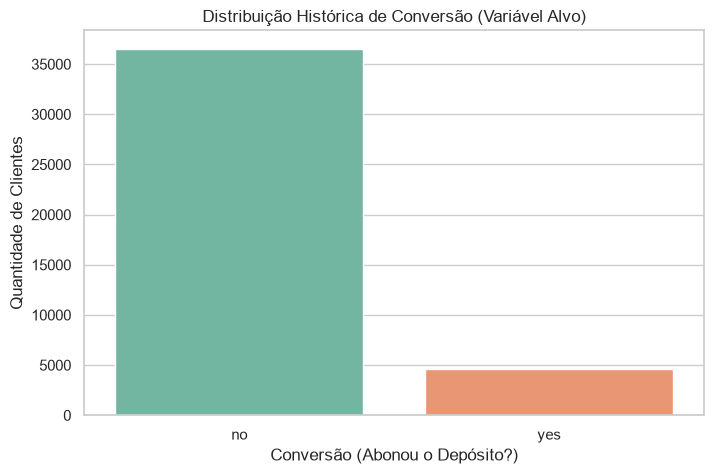

In [3]:
# ==============================================================================
# BLOCO 3: EDA - ANÁLISE DA VARIÁVEL ALVO (CONVERSÃO)
# ==============================================================================
print("--- Distribuição Absoluta ---")
print(df_raw['y'].value_counts())

print("\n--- Taxa de Conversão Histórica (Percentual) ---")
print(df_raw['y'].value_counts(normalize=True) * 100)

# Plot da distribuição
plt.figure()
sns.countplot(data=df_raw, x='y', hue='y', legend=False, palette='Set2')
plt.title('Distribuição Histórica de Conversão (Variável Alvo)')
plt.xlabel('Conversão (Abonou o Depósito?)')
plt.ylabel('Quantidade de Clientes')
plt.show()

In [ ]:
# ==============================================================================
# BLOCO 4: PREPARAÇÃO - REMOÇÃO DE DATA LEAKAGE
# ==============================================================================
# Descarte obrigatório da coluna 'duration'
df_clean = df_raw.drop(columns=['duration'])

print("✅ Coluna 'duration' removida.")
print(f"Novas dimensões do dataset: {df_clean.shape}")

✅ Coluna 'duration' removida.
Novas dimensões do dataset: (41188, 20)


In [5]:
# ==============================================================================
# BLOCO 5: PREPARAÇÃO - CRIAÇÃO DA VARIÁVEL DE RECOMPENSA (REWARD)
# ==============================================================================
# 'yes' vira 1 (sucesso/conversão) e 'no' vira 0 (falha)
df_clean['reward'] = df_clean['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Removemos a coluna 'y' original para evitar duplicidade
df_clean = df_clean.drop(columns=['y'])

print("✅ Variável alvo convertida para 'reward' (0 ou 1).")
print(df_clean['reward'].value_counts(normalize=True))

✅ Variável alvo convertida para 'reward' (0 ou 1).
reward
0    0.887346
1    0.112654
Name: proportion, dtype: float64


In [ ]:
# ==============================================================================
# BLOCO 6: PREPARAÇÃO - ONE-HOT ENCODING E EXPORTAÇÃO
# ==============================================================================
# Identifica colunas categóricas remanescentes
cat_cols = df_clean.select_dtypes(include=['object']).columns
print(f"Colunas categóricas que serão transformadas: {list(cat_cols)}")

# Aplica One-Hot Encoding
df_prepared = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Garante que o diretório de destino existe
os.makedirs('../data', exist_ok=True)

# Salva a base tratada
output_path = '../data/bank_prepared.csv'
df_prepared.to_csv(output_path, index=False)

print("\n✅ Etapa 1 e 2 Concluídas!")
print(f"Base preparada salva com sucesso em: '{output_path}'")
print(f"Shape final da base pronta: {df_prepared.shape}")

Colunas categóricas que serão transformadas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

✅ Etapa 1 e 2 Concluídas!
Base preparada salva com sucesso em: '../data/bank_prepared.csv'
Shape final da base pronta: (41188, 53)


In [7]:
# ==============================================================================
# BLOCO 7: BASELINE - POLÍTICA DE CONTROLE ESTÁTICA (TESTE A/B)
# ==============================================================================
# Isolando as colunas de decisão (canal) e recompensa
df_sim = df_prepared[['contact_telephone', 'reward']].copy()
df_sim['contact_telephone'] = df_sim['contact_telephone'].astype(int)

baseline_rewards = []
baseline_pulls = {0: 0, 1: 0}

# Simulação passando linha por linha (Simulação de Eventos)
for _, row in df_sim.iterrows():
    historical_arm = int(row['contact_telephone'])
    reward = int(row['reward'])
    
    # Política Baseline: Distribuição uniforme estática (50/50)
    chosen_arm = random.choice([0, 1])
    
    # Replay Method: Só computamos o resultado se a decisão do algoritmo 
    # coincidir com o que de fato aconteceu no histórico da base factual
    if chosen_arm == historical_arm:
        baseline_pulls[chosen_arm] += 1
        baseline_rewards.append(reward)

taxa_baseline = sum(baseline_rewards) / len(baseline_rewards)

print("--- 📊 Resultados do Baseline Determinístico ---")
print(f"Eventos avaliados (coincidências de histórico): {len(baseline_rewards)}")
print(f"Toques no Canal Celular (0): {baseline_pulls[0]} vezes")
print(f"Toques no Canal Telefone Fixo (1): {baseline_pulls[1]} vezes")
print(f"Taxa Média de Conversão do Baseline: {taxa_baseline:.4%}")

--- 📊 Resultados do Baseline Determinístico ---
Eventos avaliados (coincidências de histórico): 20732
Toques no Canal Celular (0): 13185 vezes
Toques no Canal Telefone Fixo (1): 7547 vezes
Taxa Média de Conversão do Baseline: 11.4075%


In [8]:
# ==============================================================================
# BLOCO 8: ALGORITMO ADAPTATIVO - THOMPSON SAMPLING (MULTI-ARMED BANDIT)
# ==============================================================================
# Inicialização dos Priors (Alpha = Sucessos, Beta = Falhas). 1,1 significa incerteza total.
priors = {
    0: {'alpha': 1, 'beta': 1},  # Celular
    1: {'alpha': 1, 'beta': 1}   # Telefone Fixo
}

ts_rewards = []
ts_pulls = {0: 0, 1: 0}

for _, row in df_sim.iterrows():
    historical_arm = int(row['contact_telephone'])
    reward = int(row['reward'])
    
    # Exploração Bayesiana: Amostrando da distribuição de cada braço
    theta_0 = np.random.beta(priors[0]['alpha'], priors[0]['beta'])
    theta_1 = np.random.beta(priors[1]['alpha'], priors[1]['beta'])
    
    # Decisão (Explotação do braço com maior recompensa esperada amostrada)
    chosen_arm = 0 if theta_0 > theta_1 else 1
    
    # Replay Method para avaliação offline legítima
    if chosen_arm == historical_arm:
        ts_pulls[chosen_arm] += 1
        ts_rewards.append(reward)
        
        # Aprendizado em tempo de execução: Atualizando os parâmetros do braço escolhido
        if reward == 1:
            priors[chosen_arm]['alpha'] += 1
        else:
            priors[chosen_arm]['beta'] += 1

taxa_ts = sum(ts_rewards) / len(ts_rewards)
uplift = (taxa_ts / taxa_baseline) - 1

print("--- 🤖 Resultados do Thompson Sampling ---")
print(f"Eventos avaliados (coincidências de histórico): {len(ts_rewards)}")
print(f"Toques no Canal Celular (0): {ts_pulls[0]} vezes")
print(f"Toques no Canal Telefone Fixo (1): {ts_pulls[1]} vezes")
print(f"Taxa Média de Conversão do Modelo Adaptativo: {taxa_ts:.4%}")
print(f"🚀 Ganho de Performance (Uplift) sobre o Baseline: {uplift:.2%}")

--- 🤖 Resultados do Thompson Sampling ---
Eventos avaliados (coincidências de histórico): 26167
Toques no Canal Celular (0): 25605 vezes
Toques no Canal Telefone Fixo (1): 562 vezes
Taxa Média de Conversão do Modelo Adaptativo: 14.6291%
🚀 Ganho de Performance (Uplift) sobre o Baseline: 28.24%


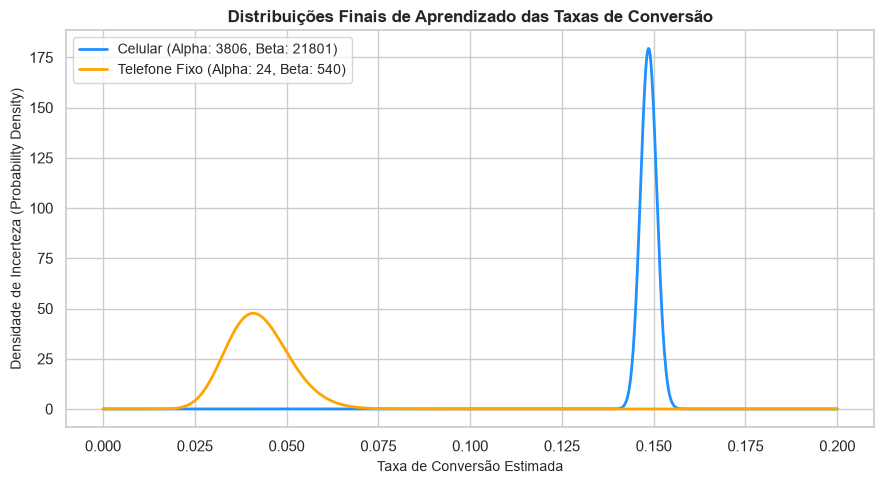

In [9]:
# ==============================================================================
# BLOCO 9: ANÁLISE DE EXPLORAÇÃO E CURVAS DE DENSIDADE (BETA PDF)
# ==============================================================================
x = np.linspace(0, 0.2, 1000)
y_celular = beta.pdf(x, priors[0]['alpha'], priors[0]['beta'])
y_fixo = beta.pdf(x, priors[1]['alpha'], priors[1]['beta'])

plt.figure(figsize=(9, 5))
plt.plot(x, y_celular, label=f"Celular (Alpha: {priors[0]['alpha']}, Beta: {priors[0]['beta']})", color='dodgerblue', lw=2)
plt.plot(x, y_fixo, label=f"Telefone Fixo (Alpha: {priors[1]['alpha']}, Beta: {priors[1]['beta']})", color='orange', lw=2)
plt.title('Distribuições Finais de Aprendizado das Taxas de Conversão', fontsize=12, fontweight='bold')
plt.xlabel('Taxa de Conversão Estimada', fontsize=10)
plt.ylabel('Densidade de Incerteza (Probability Density)', fontsize=10)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [10]:
# ==============================================================================
# BLOCO 10: AVALIAÇÃO - CRIAÇÃO DO GOLDEN SET (5 EXEMPLOS DE CLIENTES)
# ==============================================================================
# Semente fixa para garantir reprodutibilidade nos 5 clientes
random.seed(42)
np.random.seed(42)

# Amostramos 5 registros do DataFrame original (para lermos o perfil de forma humana)
golden_set = df_raw.sample(5, random_state=42)

print("--- 🎯 Golden Set Simplificado (Avaliação de Casos) ---")
print("Simulando as decisões do modelo com base no conhecimento bayesiano acumulado:\n")

for idx, row in golden_set.iterrows():
    # O modelo faz uma simulação amostrando das distribuições aprendidas
    theta_celular = np.random.beta(priors[0]['alpha'], priors[0]['beta'])
    theta_fixo = np.random.beta(priors[1]['alpha'], priors[1]['beta'])
    
    # Tomada de decisão inteligente
    canal_recomendado = "Celular (Braço 0)" if theta_celular > theta_fixo else "Telefone Fixo (Braço 1)"
    
    print(f"ID do Cliente no Dataset: {idx}")
    print(f"  ↳ Perfil: {row['age']} anos | Profissão: {row['job']} | Estado Civil: {row['marital']} | Educação: {row['education']}")
    print(f"  ↳ Canal Recomendado pelo Modelo: {canal_recomendado}")
    print(f"  ↳ Métrica Amostrada na Rodada -> Prob. Celular: {theta_celular:.4f} | Prob. Telefone Fixo: {theta_fixo:.4f}")
    
    # Justificativa de negócio
    if theta_celular > theta_fixo:
        print("  ↳ Justificativa: O modelo explota o canal Celular porque a densidade estatística acumulada provou que ele converte cerca de 3x mais que o telefone fixo, maximizando a receita da campanha.")
    else:
        print("  ↳ Justificativa: Rodada de exploração pontual ou amostragem estatística favorável ao telefone fixo.")
    print("-" * 90)

--- 🎯 Golden Set Simplificado (Avaliação de Casos) ---
Simulando as decisões do modelo com base no conhecimento bayesiano acumulado:

ID do Cliente no Dataset: 32884
  ↳ Perfil: 57 anos | Profissão: technician | Estado Civil: married | Educação: high.school
  ↳ Canal Recomendado pelo Modelo: Celular (Braço 0)
  ↳ Métrica Amostrada na Rodada -> Prob. Celular: 0.1498 | Prob. Telefone Fixo: 0.0405
  ↳ Justificativa: O modelo explota o canal Celular porque a densidade estatística acumulada provou que ele converte cerca de 3x mais que o telefone fixo, maximizando a receita da campanha.
------------------------------------------------------------------------------------------
ID do Cliente no Dataset: 3169
  ↳ Perfil: 55 anos | Profissão: unknown | Estado Civil: married | Educação: unknown
  ↳ Canal Recomendado pelo Modelo: Celular (Braço 0)
  ↳ Métrica Amostrada na Rodada -> Prob. Celular: 0.1512 | Prob. Telefone Fixo: 0.0374
  ↳ Justificativa: O modelo explota o canal Celular porque a dens

In [11]:
# ==============================================================================
# BLOCO 11: EXPORTAÇÃO DOS PARÂMETROS PARA GOVERNANÇA E SERVIÇO
# ==============================================================================
print("--- 📌 Parâmetros Prontos para Produção (Etapa 5 e 7) ---")
print(f"ALPHA_CELULAR = {priors[0]['alpha']}")
print(f"BETA_CELULAR = {priors[0]['beta']}")
print(f"ALPHA_FIXO = {priors[1]['alpha']}")
print(f"BETA_FIXO = {priors[1]['beta']}")
print("\n✅ Parabéns! O ciclo do notebook 'eda_e_preparacao.ipynb' foi finalizado do zero com sucesso de ponta a ponta.")

--- 📌 Parâmetros Prontos para Produção (Etapa 5 e 7) ---
ALPHA_CELULAR = 3806
BETA_CELULAR = 21801
ALPHA_FIXO = 24
BETA_FIXO = 540

✅ Parabéns! O ciclo do notebook 'eda_e_preparacao.ipynb' foi finalizado do zero com sucesso de ponta a ponta.
